In [134]:
import matplotlib.pyplot as plt
import matplotlib
# font options
font = {
#     'family' : 'normal',
    #'weight' : 'bold',
    'size'   : 22
}
matplotlib.rc('font', **{'family': 'serif', })
plt.rc('font', **font)
plt.rc('lines', linewidth=3, markersize=10)
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [135]:
# expe3_results= {
#     "MFLD contour": {
#         "X_fin": None
#     },
#     "MFLD": {
#         "X_fin": None,
#         "KGD_values": None,
#         "gradL_eval": None
#     },

#     "Extensible Sampling": {
#         "X_fin": None,
#         "KGD_values": None,
#         "gradL_eval": None},

#     "Variational Gradient Descent": {
#         "X_fin": None,
#         "KGD_values": None,
#         "gradL_eval": None
#     }
# }

In [136]:
gamma = 10.0
kernel_name = "imq"
filename = f"saved_data/expe3_results_gamma_{gamma}_{kernel_name}.pkl"

In [137]:
# import pickle

# # Save
# with open(filename, "wb") as gg:
#     pickle.dump(expe3_results, gg)

In [138]:
import jax.numpy as jnp
import pickle

# Chargement depuis le fichier
with open(filename, "rb") as g:
    expe3_results_loaded = pickle.load(g)

In [139]:
def kde_mfld(x):
    X = expe3_results_loaded["MFLD contour"]["X_fin"][:,:2]
    std_x = jnp.std(X[:, 0])
    n = X.shape[0]
    h = std_x / n**(1/6)

    diff = (X - x) / h
    sq_dist = jnp.sum(diff**2, axis=1)

    norm_const = 1.0 / (n * (2 * jnp.pi)**(X.shape[1] / 2) * h**X.shape[1])

    density = norm_const * jnp.sum(jnp.exp(-0.5 * sq_dist))
    return density

kernel used for KGD evaluation: imq


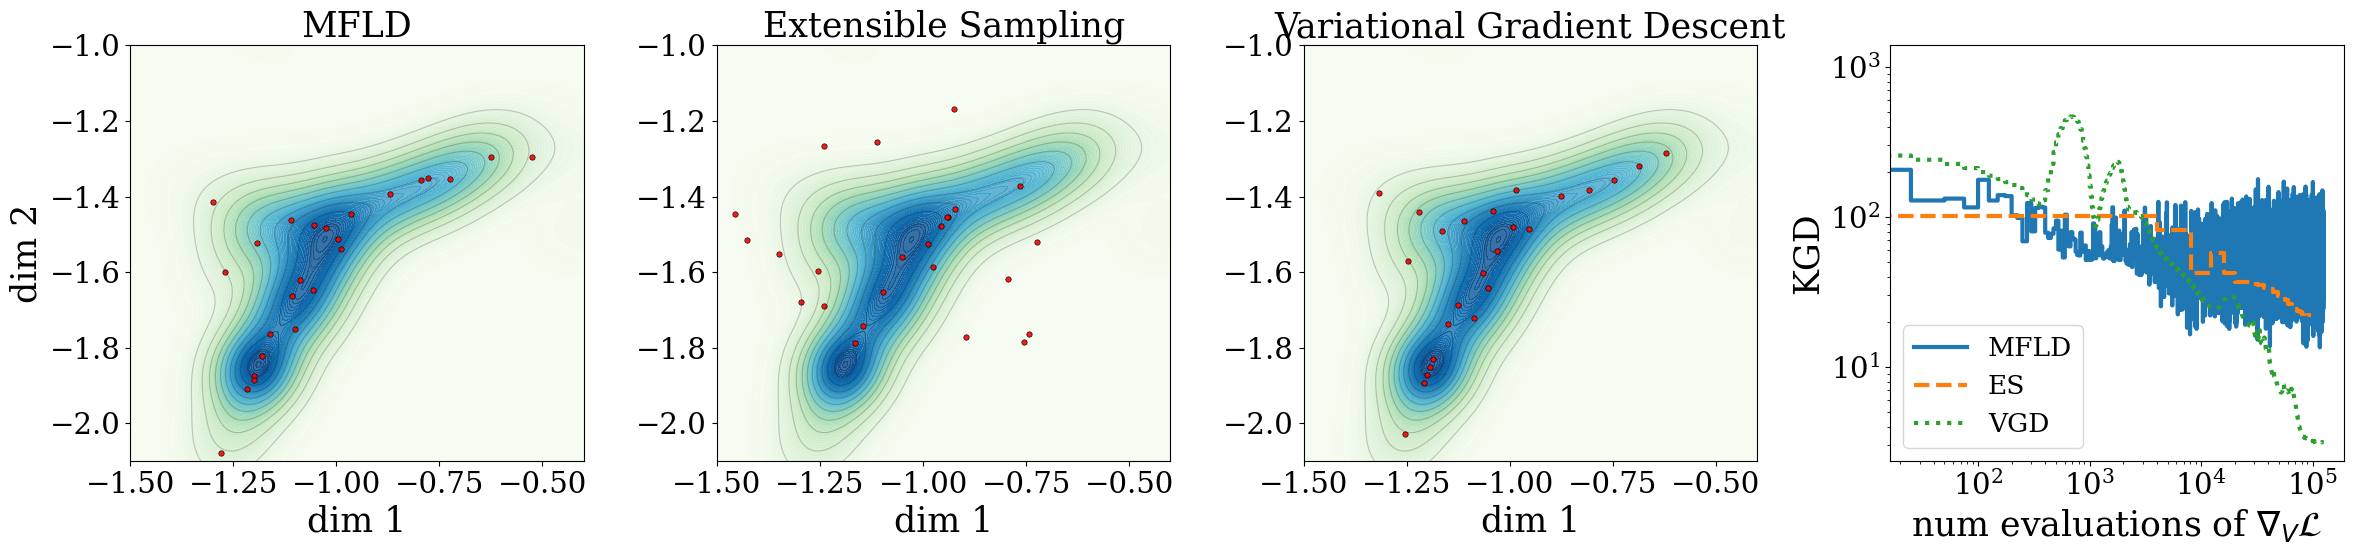

In [ ]:
import jax.numpy as jnp
import matplotlib.pyplot as plt


x = jnp.linspace(-1.5, -0.4, 200)
y = jnp.linspace(-2.1, -1.0, 200)
X, Y = jnp.meshgrid(x, y)
Z = jnp.array([[kde_mfld(jnp.array([x, y])) for x in x] for y in y])


fig, axes = plt.subplots(1, 4, figsize=(16*1.5, 4*1.5))

for ind, expe in enumerate(list(expe3_results_loaded.keys())[1:]):
    
    
    cf = axes[ind].contourf(
        X, Y, Z, 
        levels=100,        
        cmap='GnBu', 
        alpha=0.8     
    )
    
    
    axes[ind].contour(
        X, Y, Z, 
        levels=10, 
        colors='black', 
        linewidths=0.8,
        alpha=0.2
    )
    
   
    axes[ind].scatter(
        expe3_results_loaded[expe]["X_fin"][:, 0],
        expe3_results_loaded[expe]["X_fin"][:, 1],
        label="final particles",
        c='red',
        edgecolor='black',
        linewidth=0.5,
        s=15,
        alpha=0.9
    )
    
    axes[ind].set_title(expe)
    axes[ind].set_xlabel('dim 1')
    axes[ind].set_ylabel('dim 2')
    #axes[ind].legend()
axes[1].set_ylabel("")
axes[2].set_ylabel("")

tab_ODE_solved = 10**2 * jnp.arange(0,5000) #25
axes[3].set_facecolor('white')

axes[3].step(expe3_results_loaded["MFLD"]["gradL_eval"],
    expe3_results_loaded["MFLD"]["KGD_values"], 
    label="MFLD", 
    linestyle='-'
)
axes[3].step(expe3_results_loaded["Extensible Sampling"]["gradL_eval"],
    expe3_results_loaded["Extensible Sampling"]["KGD_values"], 
    label="ES", 
    linestyle='--'
)
axes[3].step(expe3_results_loaded["Variational Gradient Descent"]["gradL_eval"],
    expe3_results_loaded["Variational Gradient Descent"]["KGD_values"], 
    label="VGD", 
    linestyle=':'
)
axes[3].legend()
axes[3].set_xscale("log")
axes[3].set_yscale("log")
axes[3].set_xlabel(r"num evaluations of $\nabla_V \mathcal{L}$")
axes[3].set_ylabel("KGD")
plt.tight_layout()



print("kernel used for KGD evaluation: " + kernel_name)
plt.show()

# Evolution of distributions

In [107]:
# expe3_evol_particles= {
#     "MFLD": {
#         "iterations_gradL" : None,
#         "particles_position": None
#     },

#     "Extensible Sampling": {
#         "iterations_gradL" : None,
#         "particles_position": None
#     },

#     "Variational Gradient Descent": {
#         "iterationsgrad_gradL" : None,
#         "particles_position": None
#     }
# }

In [108]:
gamma = 10.0
kernel_name = "recommended_kernel"
expe3_filename_evol_particles = f"saved_data/expe3_evol_particles_{gamma}_{kernel_name}.pkl"

In [109]:
# import pickle

# # Save
# with open(expe3_filename_evol_particles, "wb") as gg:
#     pickle.dump(expe3_evol_particles, gg)

In [110]:
import jax.numpy as jnp
import pickle

# Load
with open(expe3_filename_evol_particles, "rb") as g:
    expe3_evol_particles_loaded = pickle.load(g)

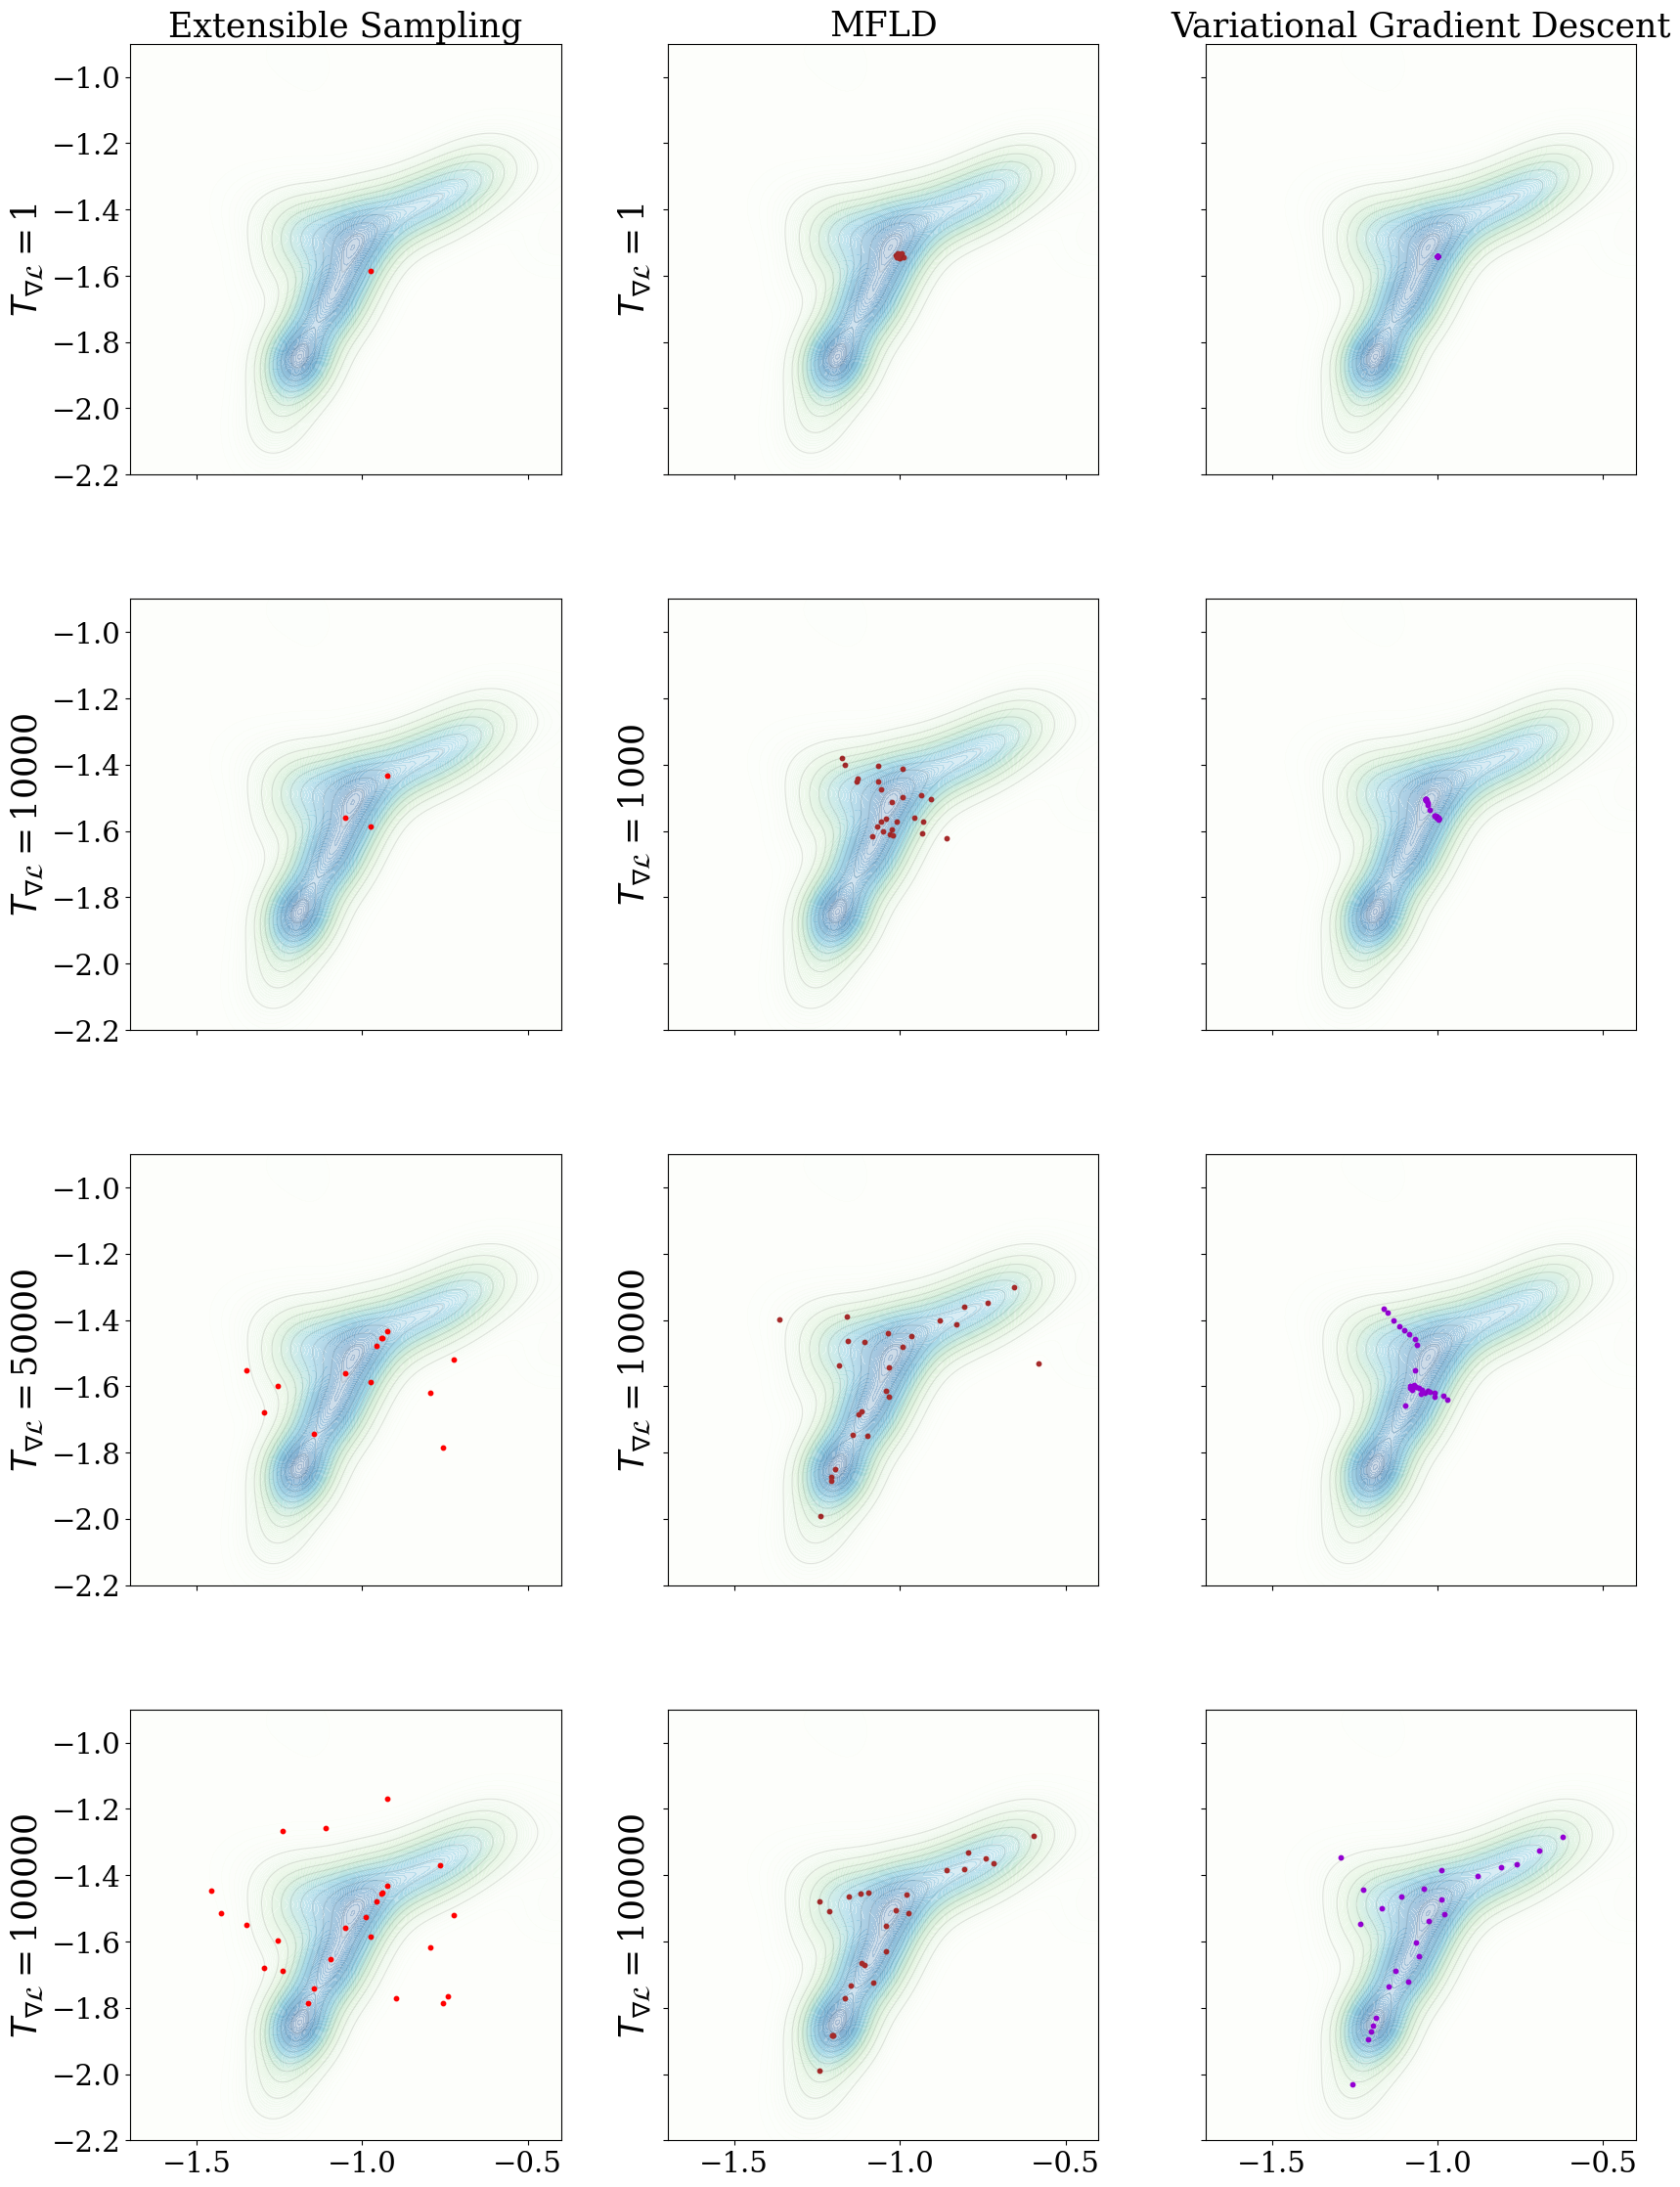

In [ ]:
fig, axes = plt.subplots(4, 3, figsize=(12*1.5, 16*1.5))
labels = ["MFLD", "ES", "VGD"]
colours = ["red", "brown", "darkviolet"]

x = jnp.linspace(-1.7, -0.4, 200)
y = jnp.linspace(-2.2, -0.9, 200)
X, Y = jnp.meshgrid(x, y)
Z = jnp.array([[kde_mfld(jnp.array([x, y])) for x in x] for y in y])

plt.rcParams.update({
    'axes.titlesize': 25,
    'axes.labelsize': 25,
    'xtick.labelsize': 21,
    'ytick.labelsize': 21,
    'legend.fontsize': 19,
    'figure.titlesize': 25
})

list_expes = [list(expe3_evol_particles_loaded.keys())[1],list(expe3_evol_particles_loaded.keys())[0],list(expe3_evol_particles_loaded.keys())[2]]
for ind, expe in enumerate(list_expes):
    for i, it_gradL in enumerate(expe3_evol_particles_loaded[expe]["iterations_gradL"]):

        ax = axes[i, ind]

        cf = ax.contourf(X, Y, Z, levels=100, cmap='GnBu', alpha=0.2)
        ax.contour(X, Y, Z, levels=10, colors='black', linewidths=0.8, alpha=0.1)

        ax.scatter(
            expe3_evol_particles_loaded[expe]["particles_position"][i][:, 0],
            expe3_evol_particles_loaded[expe]["particles_position"][i][:, 1],
            label=labels[ind], s=10, c=colours[ind]
        )

        ax.set_aspect('equal', adjustable='box')  

        if ind != 0:
            ax.set_yticklabels([])
            ax.set_ylabel("")

        if ind == 0 or ind == 1:
            ax.set_ylabel(r"$ T_{\nabla \mathcal{L}}= $" + str(it_gradL))

        if i != 3:
            ax.set_xticklabels([])
            ax.set_xlabel("")

        if i == 0:
            ax.set_title(expe)

plt.tight_layout(pad=2.0, h_pad=2.0, w_pad=2.0)

plt.show()